# Wholesale Credit Portfolio Stress Testing  
## Full Notebook — Merton PDs, Factor Calibration, Correlated Defaults, and Portfolio Credit Risk

### Project goal

This notebook builds a simplified but rigorous **wholesale credit portfolio stress-testing framework** using real public-company data.

The project has four stages:

1. **Construct a corporate borrower universe** using real public companies.
2. **Estimate firm-level structural default risk** using a simplified Merton-style distance-to-default framework.
3. **Calibrate market and sector factor exposures** using stock and ETF returns.
4. **Simulate correlated portfolio defaults** to estimate portfolio loss distribution, Credit VaR, Expected Shortfall, economic capital, and sector tail-risk attribution.

## 1. Structural-credit intuition

The Merton model treats a firm's equity as a call option on its assets.

Let:

$$
A_t = \text{firm asset value}
$$

$$
K = \text{debt face value or default barrier}
$$

Default occurs when:

$$
A_T < K
$$

Equity holders receive:

$$
E_T = (A_T - K)^+
$$

The true asset value is not directly observable, so this project uses observable public-company data:

| Model concept | Practical proxy |
|---|---|
| Equity value $(E)$ | Market capitalization |
| Default barrier $(K)$ | Total debt |
| Equity volatility $(\sigma_E)$ | Annualized stock-return volatility |
| Market factor | SPY return |
| Sector factor | Sector ETF return |

## 2. Portfolio-credit intuition

Single-firm PDs are not enough for portfolio credit risk.

Defaults cluster because firms share exposure to:

- market-wide recessions,
- sector downturns,
- idiosyncratic firm shocks.

We use a multi-factor latent asset-return model:

$$
Y_i = \beta_i M + \gamma_i I_{s(i)} + \sqrt{1-\beta_i^2-\gamma_i^2}\epsilon_i
$$

A firm defaults if:

$$
Y_i < \Phi^{-1}(PD_i)
$$

## 3. Install and import packages

In [1]:
# Run once if yfinance is not installed.
# %pip install yfinance --upgrade --no-cache-dir

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from scipy.stats import norm
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("yfinance version:", yf.__version__)

yfinance version: 1.4.0


## 4. Define company universe and factor ETFs

Each ticker is treated as a corporate borrower, not as an equity holding. The stock data is used because public companies provide observable market capitalization and equity volatility, which are useful proxies for firm-level structural credit risk.

The sector ETF mapping gives each borrower an industry risk factor. Later, this lets the model distinguish broad market shocks from sector-specific shocks.

In [2]:
company_universe = {
    "Technology": ["AAPL", "MSFT", "NVDA", "CRM", "ORCL", "ADBE", "CSCO", "INTC"],
    "Energy": ["XOM", "CVX", "COP", "EOG", "SLB", "MPC", "PSX", "VLO"],
    "Industrials": ["CAT", "BA", "GE", "HON", "UNP", "UPS", "RTX", "LMT"],
    "Consumer": ["WMT", "TGT", "COST", "HD", "LOW", "MCD", "SBUX", "NKE"],
    "Healthcare": ["JNJ", "PFE", "MRK", "ABBV", "UNH", "TMO", "ABT", "BMY"],
    "Financials": ["JPM", "BAC", "GS", "MS", "C", "WFC", "BLK", "AXP"],
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "O", "PSA", "WELL", "DLR"]
}

sector_etfs = {
    "Technology": "XLK",
    "Energy": "XLE",
    "Industrials": "XLI",
    "Consumer": "XLY",
    "Healthcare": "XLV",
    "Financials": "XLF",
    "Real Estate": "XLRE"
}

## 5. Flatten tickers and download price data

The universe is stored by sector for readability, but market data APIs require a flat list of tickers. We also download SPY and sector ETFs because those returns become explanatory factors in the later factor-loading regression.

This data supports two tasks: estimating each firm's equity volatility and estimating each firm's sensitivity to market and sector movements.

In [3]:
tickers = []
for sector_name, sector_tickers in company_universe.items():
    tickers.extend(sector_tickers)

factor_tickers = ["SPY"] + list(sector_etfs.values())
all_tickers = sorted(list(set(tickers + factor_tickers)))

print("Number of company tickers:", len(tickers))
print("Number of factor tickers:", len(factor_tickers))
print("Total unique tickers:", len(all_tickers))

Number of company tickers: 56
Number of factor tickers: 8
Total unique tickers: 64


In [4]:
prices = yf.download(
    all_tickers,
    start="2019-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False
)["Close"]

prices.head()

c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages\yfinance\scrapers\history.py:396: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  self._capital_gains = pd.Series()
c:\Users\Binhe Jia\AppData\Local\Programs\Python\Python310\lib\site-packages

Ticker,AAPL,ABBV,ABT,ADBE,AMT,AXP,BA,BAC,BLK,BMY,C,CAT,COP,COST,CRM,CSCO,CVX,DLR,EOG,EQIX,GE,GS,HD,HON,INTC,JNJ,JPM,LMT,LOW,MCD,MPC,MRK,MS,MSFT,NKE,NVDA,O,ORCL,PFE,PLD,PSA,PSX,RTX,SBUX,SLB,SPG,SPY,TGT,TMO,UNH,UNP,UPS,VLO,WELL,WFC,WMT,XLE,XLF,XLI,XLK,XLRE,XLV,XLY,XOM
2019-01-02,37.469208,64.789436,60.801220,224.570007,129.213242,86.626465,314.645142,20.945087,325.040955,39.592640,41.436657,108.023575,49.032207,184.861771,133.588699,34.472202,79.872681,80.475792,67.100464,303.811646,37.317692,145.391647,144.203751,106.344002,40.518047,104.387878,80.836510,218.160965,80.339264,148.797745,47.206024,57.638226,32.141247,94.193130,67.154182,3.376984,42.167568,40.505600,28.818653,46.672779,144.748489,65.383194,57.343647,54.597130,30.385839,110.938286,224.382523,53.870190,215.256546,215.453156,117.373749,71.712975,56.109127,53.431438,38.257420,27.913780,21.123751,20.933620,57.430752,29.032202,23.826706,75.273270,46.654293,49.664734
2019-01-03,33.737000,62.654716,57.931751,215.699997,129.988144,84.935562,302.100555,20.609421,315.492157,34.341015,40.685806,103.860962,48.103855,180.943542,128.513199,33.218506,78.342888,80.070236,66.626518,300.287445,37.364040,143.261887,141.025452,104.924248,38.289040,102.729111,79.687683,212.680756,79.381523,147.817383,46.517410,56.456333,31.568417,90.727974,65.966331,3.172956,42.542068,40.111477,28.012398,46.296318,147.523849,64.477982,54.791485,52.228878,30.712566,110.844185,219.028152,53.132355,208.144180,209.577698,113.029106,69.676895,55.099213,54.416061,37.955856,27.770229,20.914246,20.463011,55.683182,27.567017,23.936825,73.744865,45.644138,48.902203
2019-01-04,35.177197,64.673264,59.585197,226.190002,130.507507,88.762817,317.822571,21.465357,327.044189,35.688179,42.675190,109.536491,49.318451,186.197937,135.963821,34.714844,79.966492,81.739197,69.551636,307.101471,38.152126,147.944061,145.215805,108.594620,40.638542,104.453262,82.625404,218.416473,81.732422,150.673996,48.796986,58.156734,32.857254,94.947632,67.689186,3.376239,42.528419,41.840256,28.652077,47.466602,145.891312,67.401367,56.665882,53.960499,31.929644,112.531700,226.364655,53.862080,217.552155,212.028778,117.382256,72.103928,57.185871,54.217541,39.080601,27.943680,21.625835,21.142786,57.794453,28.788780,24.180683,75.944748,47.154690,50.705227
2019-01-07,35.098907,65.617188,60.477528,229.259995,131.315384,89.244614,318.823456,21.448568,327.953918,36.845051,43.046761,109.604881,49.101826,186.884125,140.162216,34.949402,81.005585,82.823212,69.988564,307.717804,40.516350,148.763824,148.076263,109.199623,40.827873,103.783218,82.682846,220.921600,83.282242,152.313599,49.279800,57.516212,33.183426,95.068733,68.659401,3.554980,42.405872,42.503117,28.805325,48.235897,145.483170,67.868820,56.639397,53.960499,32.811806,113.714943,228.149414,56.497208,220.485443,212.435822,118.114914,71.860519,57.245266,54.860733,38.827930,28.272642,21.947317,21.168930,58.264618,29.046247,24.385201,76.236298,48.220974,50.968899
2019-01-08,35.768009,65.922150,59.751404,232.679993,132.799271,89.680977,330.891907,21.406612,332.127380,36.525387,42.930641,110.921227,49.759411,188.283493,143.611542,35.232491,80.652008,83.712280,70.736496,314.106567,39.681915,148.214462,148.787247,108.973732,41.086067,106.193756,82.526924,222.396805,85.006233,152.634750,49.762619,57.943226,32.976585,95.758064,69.575203,3.466478,43.025475,42.888287,28.938593,49.839954,148.095230,67.809486,57.661304,54.002937,33.220215,116.431084,230.293015,56.440445,225.616211,215.276184,128.422791,71.867867,57.445759,55.829460,38.746433,28.470015,22.117086,21.186361,59.063015,29.289663,24.809975,76.828232,48.754124,51.339481


## 6. Convert prices into returns

Returns are used instead of prices because volatility, covariance, correlation, and regression betas are defined on returns. The first return observation is missing because a percentage change requires a previous price.

The return matrix is the foundation for both single-firm volatility estimation and portfolio correlation modeling.

In [5]:
returns = prices.pct_change().dropna()

print("Return matrix shape:", returns.shape)
returns[["SPY", "XLK", "XLE", "XLI"]].head()

Return matrix shape: (1508, 64)


Ticker,SPY,XLK,XLE,XLI
2019-01-03,-0.023863,-0.050468,-0.009918,-0.030429
2019-01-04,0.033496,0.044320,0.034024,0.037916
2019-01-07,0.007884,0.008943,0.014866,0.008135
2019-01-08,0.009396,0.008380,0.007735,0.013703
2019-01-09,0.004673,0.012945,0.015842,0.006759


## 7. Build company metadata table

This table is the borrower master file. It begins with ticker, sector, and sector ETF, then later receives market cap, debt, volatility, PD, factor loadings, EAD, and LGD.

In a real bank, this would be analogous to a credit exposure table with borrower identifiers and industry classifications.

In [6]:
company_rows = []

for sector_name, sector_tickers in company_universe.items():
    for ticker in sector_tickers:
        company_rows.append({
            "ticker": ticker,
            "sector_group": sector_name,
            "sector_etf": sector_etfs[sector_name]
        })

company_df = pd.DataFrame(company_rows)

print(company_df.shape)
company_df.head()

(56, 3)


,ticker,sector_group,sector_etf
0,AAPL,Technology,XLK
1,MSFT,Technology,XLK
2,NVDA,Technology,XLK
3,CRM,Technology,XLK
4,ORCL,Technology,XLK


## 8. Pull market capitalization and debt data

For the first version:

$$
E = \text{market capitalization}
$$

$$
K = \text{total debt}
$$

A more refined KMV-style default point would be:

$$
K = \text{short-term debt} + 0.5 \times \text{long-term debt}
$$

but total debt is a transparent first approximation.

Market capitalization is used as observed equity value. Total debt is used as a first-pass default barrier. This is a practical simplification of the Merton/KMV idea, where a firm defaults if asset value falls below a debt threshold.

Using total debt is transparent and easy to audit, but it is not perfect. A later refinement could use short-term debt plus half of long-term debt as a KMV-style default point.

In [7]:
metadata_rows = []

for ticker in company_df["ticker"]:
    tk = yf.Ticker(ticker)
    info = tk.info

    metadata_rows.append({
        "ticker": ticker,
        "market_cap": info.get("marketCap"),
        "total_debt": info.get("totalDebt"),
        "enterprise_value": info.get("enterpriseValue"),
        "shares_outstanding": info.get("sharesOutstanding"),
        "industry": info.get("industry"),
        "sector_yfinance": info.get("sector")
    })

metadata_df = pd.DataFrame(metadata_rows)
company_df = company_df.merge(metadata_df, on="ticker", how="left")

company_df.head()

,ticker,sector_group,sector_etf,market_cap,total_debt,enterprise_value,shares_outstanding,industry,sector_yfinance
0,AAPL,Technology,XLK,4535749181440,84710998016,4551953350656,14687356000,Consumer Electronics,Technology
1,MSFT,Technology,XLK,3109320130560,125431996416,3156523876352,7428434704,Software - Infrastructure,Technology
2,NVDA,Technology,XLK,5215507972096,12814000128,5170627870720,24221000000,Semiconductors,Technology
3,CRM,Technology,XLK,147306938368,17710999552,174350614528,818053744,Software - Application,Technology
4,ORCL,Technology,XLK,552430927872,162164998144,680973893632,2876046000,Software - Infrastructure,Technology


## 9. Check missing values

This is a data-quality checkpoint. The Merton model cannot be estimated if market cap, debt, or return history is missing.

In professional model development, exclusions and imputations must be documented because they affect model coverage and potential bias.

In [8]:
company_df.isna().mean().sort_values(ascending=False)

ticker               0.000000
sector_group         0.000000
sector_etf           0.000000
market_cap           0.000000
total_debt           0.000000
enterprise_value     0.000000
shares_outstanding   0.000000
industry             0.000000
sector_yfinance      0.000000
dtype: float64

## 10. Estimate annualized equity volatility
$$
\sigma_E = std(r_{daily}) \times \sqrt{252}
$$

Equity volatility measures how unstable a firm's market value is. In structural credit risk, higher volatility means the firm asset value has a greater chance of falling below the debt barrier.

We annualize daily volatility with square-root-of-time scaling using roughly 252 trading days per year.

In [9]:
trading_days = 252

equity_vol = returns[company_df["ticker"]].std() * np.sqrt(trading_days)
company_df["equity_vol"] = company_df["ticker"].map(equity_vol)

company_df[[
    "ticker", "sector_group", "market_cap", "total_debt", "equity_vol"
]].head()

,ticker,sector_group,market_cap,total_debt,equity_vol
0,AAPL,Technology,4535749181440,84710998016,0.308480
1,MSFT,Technology,3109320130560,125431996416,0.290044
2,NVDA,Technology,5215507972096,12814000128,0.518932
3,CRM,Technology,147306938368,17710999552,0.380142
4,ORCL,Technology,552430927872,162164998144,0.310385


## 11. Define Merton model inputs

This section translates raw market/fundamental data into Merton notation. Equity value becomes E, debt becomes K, and annualized stock volatility becomes sigma_E.

Firms with non-positive debt are removed because a default barrier of zero would make distance-to-default formulas invalid.

In [10]:
company_df["equity_value"] = company_df["market_cap"]
company_df["default_barrier"] = company_df["total_debt"]

merton_inputs = company_df.dropna(
    subset=["equity_value", "default_barrier", "equity_vol"]
).copy()

merton_inputs = merton_inputs[merton_inputs["default_barrier"] > 0].copy()

print("Merton input shape:", merton_inputs.shape)

merton_inputs[
    ["ticker", "sector_group", "equity_value", "default_barrier", "equity_vol"]
].head()

Merton input shape: (56, 12)


,ticker,sector_group,equity_value,default_barrier,equity_vol
0,AAPL,Technology,4535749181440,84710998016,0.308480
1,MSFT,Technology,3109320130560,125431996416,0.290044
2,NVDA,Technology,5215507972096,12814000128,0.518932
3,CRM,Technology,147306938368,17710999552,0.380142
4,ORCL,Technology,552430927872,162164998144,0.310385


## 12. Add leverage diagnostics

Debt-to-equity is a simple leverage measure. Higher leverage means the firm has less equity cushion relative to debt, which generally increases default risk.

The billions columns are only for readability; the model calculations still use raw dollar values.

In [11]:
merton_inputs["equity_value_bn"] = merton_inputs["equity_value"] / 1e9
merton_inputs["default_barrier_bn"] = merton_inputs["default_barrier"] / 1e9

merton_inputs["debt_to_equity"] = (
    merton_inputs["default_barrier"] / merton_inputs["equity_value"]
)

merton_inputs[[
    "ticker", "sector_group", "equity_value_bn",
    "default_barrier_bn", "debt_to_equity", "equity_vol"
]].head()

,ticker,sector_group,equity_value_bn,default_barrier_bn,debt_to_equity,equity_vol
0,AAPL,Technology,"4,535.749181",84.710998,0.018676,0.308480
1,MSFT,Technology,"3,109.320131",125.431996,0.040341,0.290044
2,NVDA,Technology,"5,215.507972",12.814000,0.002457,0.518932
3,CRM,Technology,147.306938,17.711000,0.120232,0.380142
4,ORCL,Technology,552.430928,162.164998,0.293548,0.310385


In [12]:
merton_inputs[[
    "equity_value_bn",
    "default_barrier_bn",
    "debt_to_equity",
    "equity_vol"
]].describe()

,equity_value_bn,default_barrier_bn,debt_to_equity,equity_vol
count,56.000000,56.000000,56.000000,56.000000
mean,460.202301,121.866089,0.440478,0.325566
std,961.519860,255.900304,0.733373,0.074381
min,53.585338,6.670000,0.002457,0.191541
25%,104.603105,21.165001,0.116973,0.271314
50%,166.578274,38.343000,0.205123,0.311038
75%,370.976842,61.133499,0.340687,0.368822
max,"5,215.507972","1,321.104966",3.822698,0.518932


## 13. Estimate simplified Merton distance to default and PD

Approximate asset value:

$$
V \approx E + K
$$

Approximate asset volatility:

$$
\sigma_V \approx \sigma_E \frac{E}{E+K}
$$

Distance to default:

$$
DD =
\frac{
\ln(V/K) + (\mu - 0.5\sigma_V^2)T
}{
\sigma_V\sqrt{T}
}
$$

Default probability:

$$
PD = \Phi(-DD)
$$

This is the core firm-level credit risk step. We approximate asset value as equity plus debt, then estimate asset volatility by scaling equity volatility down by the equity share of firm value.

Distance to default is the number of asset-volatility standard deviations between current firm value and the default barrier. It is analogous to a physical-measure version of Black-Scholes d2, not d1, because it is directly tied to the probability of assets ending below the debt threshold.

In [13]:
T = 1.0
mu = 0.05

merton_inputs["asset_value"] = (
    merton_inputs["equity_value"] + merton_inputs["default_barrier"]
)

merton_inputs["asset_vol"] = (
    merton_inputs["equity_vol"]
    * merton_inputs["equity_value"]
    / merton_inputs["asset_value"]
)

merton_inputs["distance_to_default"] = (
    np.log(merton_inputs["asset_value"] / merton_inputs["default_barrier"])
    + (mu - 0.5 * merton_inputs["asset_vol"] ** 2) * T
) / (merton_inputs["asset_vol"] * np.sqrt(T))

merton_inputs["merton_pd"] = norm.cdf(-merton_inputs["distance_to_default"])

merton_inputs[
    [
        "ticker", "sector_group", "debt_to_equity",
        "equity_vol", "asset_vol",
        "distance_to_default", "merton_pd"
    ]
].sort_values("merton_pd", ascending=False).head(15)

,ticker,sector_group,debt_to_equity,equity_vol,asset_vol,distance_to_default,merton_pd
44,C,Financials,3.822698,0.371062,0.076941,3.631584,0.000141
45,WFC,Financials,2.006959,0.366111,0.121754,3.670473,0.000121
13,MPC,Energy,0.461733,0.449983,0.307842,3.751950,0.000088
41,BAC,Financials,2.175989,0.339771,0.106981,3.948485,0.000039
17,BA,Industrials,0.287361,0.481177,0.373770,3.959009,0.000038
43,MS,Financials,1.827643,0.339671,0.120125,3.989180,0.000033
51,SPG,Real Estate,0.373226,0.445454,0.324385,4.007957,0.000031
42,GS,Financials,2.855595,0.317226,0.082277,4.215777,0.000012
14,PSX,Energy,0.380730,0.399719,0.289498,4.478004,0.000004
40,JPM,Financials,1.609242,0.306620,0.117513,4.479428,0.000004


## 14. Apply a PD floor

Large public companies can produce extremely small Merton PDs. In a small 56-name portfolio, that can lead to almost no defaults in simulation.

The PD floor is a transparent modeling assumption for numerical usefulness. It should not be interpreted as a fully calibrated market-implied PD.

In [14]:
pd_floor = 0.0001

merton_inputs["pd_model"] = merton_inputs["merton_pd"].clip(lower=pd_floor)

merton_inputs[
    ["ticker", "sector_group", "merton_pd", "pd_model", "distance_to_default"]
].sort_values("pd_model", ascending=False).head(15)

,ticker,sector_group,merton_pd,pd_model,distance_to_default
44,C,Financials,0.000141,0.000141,3.631584
45,WFC,Financials,0.000121,0.000121,3.670473
0,AAPL,Technology,0.000000,0.000100,13.219394
41,BAC,Financials,0.000039,0.000100,3.948485
30,SBUX,Consumer,0.000000,0.000100,6.698399
31,NKE,Consumer,0.000000,0.000100,6.915717
32,JNJ,Healthcare,0.000000,0.000100,14.071781
33,PFE,Healthcare,0.000000,0.000100,6.692982
34,MRK,Healthcare,0.000000,0.000100,10.211628
35,ABBV,Healthcare,0.000000,0.000100,8.785404


# Part II — Factor Calibration and Portfolio Simulation

## 15. Estimate market and sector factor loadings

For each firm, regress daily stock returns on:

$$
r_i = \alpha_i + b_i r_{SPY} + g_i r_{sector} + e_i
$$

The fitted coefficients are empirical sensitivities to market and sector movements.

### Additional explanation
This regression estimates how sensitive each firm's equity return is to broad market and sector movements. The coefficients are empirical proxies for systematic risk exposure.

The goal is not equity return forecasting; the goal is to create a realistic dependence structure for correlated defaults.

In [15]:
factor_rows = []

for _, row in merton_inputs.iterrows():
    ticker = row["ticker"]
    sector_etf = row["sector_etf"]

    data = returns[[ticker, "SPY", sector_etf]].dropna()

    X = data[["SPY", sector_etf]]
    y = data[ticker]

    model = LinearRegression()
    model.fit(X, y)

    factor_rows.append({
        "ticker": ticker,
        "market_beta_raw": model.coef_[0],
        "sector_beta_raw": model.coef_[1],
        "r_squared": model.score(X, y)
    })

factor_loadings = pd.DataFrame(factor_rows)
merton_inputs = merton_inputs.merge(factor_loadings, on="ticker", how="left")

merton_inputs[[
    "ticker", "sector_group", "market_beta_raw", 
    "sector_beta_raw", "r_squared"
]].head()

,ticker,sector_group,market_beta_raw,sector_beta_raw,r_squared
0,AAPL,Technology,-0.130194,1.079318,0.726315
1,MSFT,Technology,-0.140896,1.071474,0.796575
2,NVDA,Technology,-1.109031,2.343901,0.671600
3,CRM,Technology,0.083940,0.923559,0.471459
4,ORCL,Technology,0.490872,0.380160,0.394803


## 16. Convert regression betas into latent factor loadings

The simulation model requires:

$$
\beta_i^2 + \gamma_i^2 < 1
$$

so that the idiosyncratic loading is real:

$$
\sqrt{1-\beta_i^2-\gamma_i^2}
$$

### Additional explanation
Regression betas are not automatically valid Gaussian latent-factor weights. In the default simulation, the squared market loading plus squared sector loading must be less than one so the idiosyncratic loading is real.

This section rescales the empirical betas into controlled factor weights while preserving the intuition that firms with higher market or sector sensitivity should have stronger common-factor exposure.

In [16]:
merton_inputs["beta_global"] = (
    0.30 * merton_inputs["market_beta_raw"] / 
    merton_inputs["market_beta_raw"].abs().quantile(0.95)
)

merton_inputs["gamma_sector"] = (
    0.25 * merton_inputs["sector_beta_raw"] / 
    merton_inputs["sector_beta_raw"].abs().quantile(0.95)
)

merton_inputs["beta_global"] = merton_inputs["beta_global"].clip(-0.45, 0.45)
merton_inputs["gamma_sector"] = merton_inputs["gamma_sector"].clip(-0.35, 0.35)

merton_inputs["idio_weight"] = np.sqrt(
    1 - merton_inputs["beta_global"]**2 - merton_inputs["gamma_sector"]**2
)

merton_inputs[[
    "ticker", "sector_group", "beta_global",
    "gamma_sector", "idio_weight", "r_squared"
]].head()

,ticker,sector_group,beta_global,gamma_sector,idio_weight,r_squared
0,AAPL,Technology,-0.054225,0.170563,0.983854,0.726315
1,MSFT,Technology,-0.058682,0.169324,0.983812,0.796575
2,NVDA,Technology,-0.450000,0.350000,0.821584,0.671600
3,CRM,Technology,0.034960,0.145949,0.988674,0.471459
4,ORCL,Technology,0.204445,0.060076,0.977033,0.394803


## 17. Assign EAD and LGD

This is a **wholesale credit portfolio**, not an equity investment portfolio.

The public equity data is used to estimate firm-level credit risk inputs such as market capitalization, equity volatility, and distance to default. The portfolio exposure is represented by:

$$
EAD_i = \text{Exposure at Default}
$$

$$
LGD_i = \text{Loss Given Default}
$$

A credit loss for borrower \(i\) is:

$$
Loss_i = EAD_i \times LGD_i \times 1_{\{default_i\}}
$$

To avoid misleading concentration effects in the baseline result, this notebook uses two exposure designs:

1. **Equal-EAD baseline portfolio**: each borrower receives the same exposure. This creates a clean baseline where tail losses are driven mainly by PD, LGD, and default correlation rather than random exposure concentration.
2. **Concentrated-EAD portfolio**: EADs follow a capped lognormal distribution. This is used as a concentration-risk scenario.

EAD is the bank's loan exposure to each corporate borrower. LGD is the fraction lost if the borrower defaults. These are credit portfolio quantities, not stock portfolio weights.

The equal-EAD baseline provides a clean benchmark. The concentrated-EAD case represents a more realistic wholesale portfolio where some borrowers have larger facilities than others.

In [17]:
np.random.seed(42)

# Baseline portfolio: equal EAD per borrower
baseline_ead = 100_000_000
merton_inputs["ead_equal"] = baseline_ead

# Concentrated portfolio: capped lognormal EADs
raw_concentrated_ead = np.random.lognormal(
    mean=np.log(100_000_000),
    sigma=0.7,
    size=len(merton_inputs)
)

# Cap each single-name exposure at 5% of raw portfolio EAD to avoid one name dominating mechanically.
cap = 0.05 * raw_concentrated_ead.sum()
merton_inputs["ead_concentrated"] = np.clip(raw_concentrated_ead, None, cap)

# LGD assumption
merton_inputs["lgd"] = np.random.uniform(
    low=0.35,
    high=0.60,
    size=len(merton_inputs)
)

# Active exposure set for the baseline simulation.
active_ead_col = "ead_equal"

merton_inputs["ead"] = merton_inputs[active_ead_col]
merton_inputs["ead_mn"] = merton_inputs["ead"] / 1e6
merton_inputs["ead_weight"] = merton_inputs["ead"] / merton_inputs["ead"].sum()

merton_inputs[[
    "ticker", "sector_group", "pd_model", "ead_mn", "ead_weight", "lgd"
]].head()

,ticker,sector_group,pd_model,ead_mn,ead_weight,lgd
0,AAPL,Technology,0.000100,100.000000,0.017857,0.542818
1,MSFT,Technology,0.000100,100.000000,0.017857,0.368511
2,NVDA,Technology,0.000100,100.000000,0.017857,0.439616
3,CRM,Technology,0.000100,100.000000,0.017857,0.378967
4,ORCL,Technology,0.000100,100.000000,0.017857,0.565776


## 18. Portfolio exposure summary

This section describes the loan book before simulation. Risk managers first need to understand sector concentration, average PD, average LGD, and EAD distribution before interpreting VaR or stress results.

A sector with high EAD share or high average PD may contribute disproportionately to expected or tail loss.

In [18]:
portfolio_summary = (
    merton_inputs.groupby("sector_group")
    .agg(
        n_firms=("ticker", "count"),
        total_ead=("ead", "sum"),
        avg_pd=("pd_model", "mean"),
        avg_lgd=("lgd", "mean")
    )
    .reset_index()
)

portfolio_summary["total_ead_mn"] = portfolio_summary["total_ead"] / 1e6
portfolio_summary["ead_share"] = portfolio_summary["total_ead"] / portfolio_summary["total_ead"].sum()

portfolio_summary.sort_values("total_ead", ascending=False)

,sector_group,n_firms,total_ead,avg_pd,avg_lgd,total_ead_mn,ead_share
0,Consumer,8,800000000,0.000100,0.469174,800.000000,0.142857
1,Energy,8,800000000,0.000100,0.481112,800.000000,0.142857
2,Financials,8,800000000,0.000108,0.492304,800.000000,0.142857
3,Healthcare,8,800000000,0.000100,0.474982,800.000000,0.142857
4,Industrials,8,800000000,0.000100,0.464700,800.000000,0.142857
5,Real Estate,8,800000000,0.000100,0.459094,800.000000,0.142857
6,Technology,8,800000000,0.000100,0.450016,800.000000,0.142857


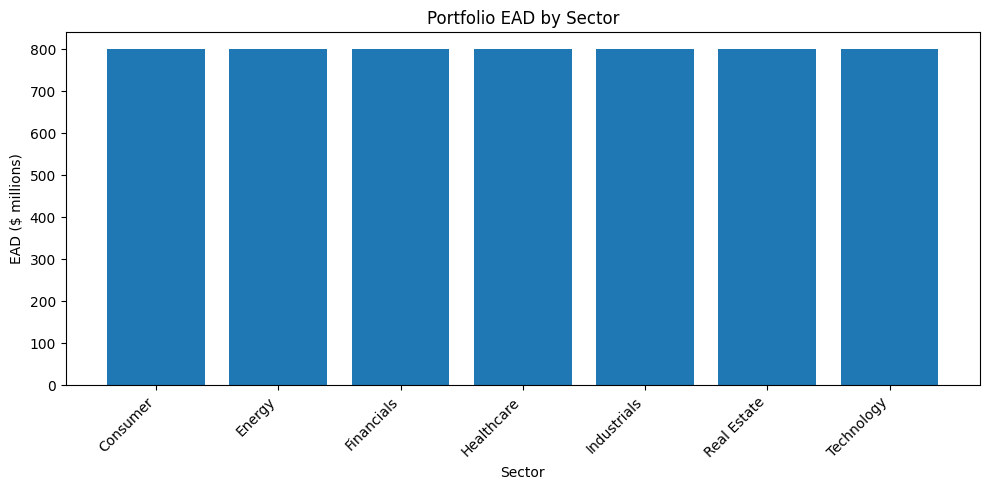

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(portfolio_summary["sector_group"], portfolio_summary["total_ead_mn"])
plt.title("Portfolio EAD by Sector")
plt.xlabel("Sector")
plt.ylabel("EAD ($ millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 18.1 Single-name and sector exposure concentration check

Before simulating defaults, check whether one borrower or one sector dominates the portfolio.

This matters because a credit portfolio's tail loss can be driven by high borrower PD, high LGD, high default correlation, or simply one very large EAD.

The equal-EAD baseline should have limited single-name concentration. The concentrated-EAD scenario will intentionally introduce more concentration.

### Additional explanation
Tail risk can be caused by credit quality, correlation, or exposure concentration. This diagnostic checks whether the model results are being mechanically dominated by one large borrower or one sector.

This is especially important when using lognormal EADs because lognormal distributions can create large outliers.

In [20]:
single_name_concentration = merton_inputs[[
    "ticker", "sector_group", "ead_mn", "ead_weight", "pd_model", "lgd"
]].sort_values("ead_weight", ascending=False)

single_name_concentration.head(15)

,ticker,sector_group,ead_mn,ead_weight,pd_model,lgd
0,AAPL,Technology,100.000000,0.017857,0.000100,0.542818
1,MSFT,Technology,100.000000,0.017857,0.000100,0.368511
30,SBUX,Consumer,100.000000,0.017857,0.000100,0.452596
31,NKE,Consumer,100.000000,0.017857,0.000100,0.538888
32,JNJ,Healthcare,100.000000,0.017857,0.000100,0.407200
33,PFE,Healthcare,100.000000,0.017857,0.000100,0.369245
34,MRK,Healthcare,100.000000,0.017857,0.000100,0.422438
35,ABBV,Healthcare,100.000000,0.017857,0.000100,0.390305
36,UNH,Healthcare,100.000000,0.017857,0.000100,0.582424
37,TMO,Healthcare,100.000000,0.017857,0.000100,0.552030


In [21]:
sector_ead_check = (
    merton_inputs.groupby("sector_group")["ead"]
    .sum()
    .reset_index()
)

sector_ead_check["ead_share"] = sector_ead_check["ead"] / sector_ead_check["ead"].sum()
sector_ead_check["ead_mn"] = sector_ead_check["ead"] / 1e6

sector_ead_check.sort_values("ead_share", ascending=False)

,sector_group,ead,ead_share,ead_mn
0,Consumer,800000000,0.142857,800.000000
1,Energy,800000000,0.142857,800.000000
2,Financials,800000000,0.142857,800.000000
3,Healthcare,800000000,0.142857,800.000000
4,Industrials,800000000,0.142857,800.000000
5,Real Estate,800000000,0.142857,800.000000
6,Technology,800000000,0.142857,800.000000


## 19. Prepare arrays for Monte Carlo simulation

### Additional explanation
This converts the dataframe into arrays for faster simulation. Each firm gets a default threshold equal to the inverse normal CDF of its PD.

In each scenario, if the simulated latent asset return falls below this threshold, the firm defaults.

In [22]:
n_sims = 50_000
n_firms = len(merton_inputs)

pd_values = merton_inputs["pd_model"].values
default_thresholds = norm.ppf(pd_values)

beta = merton_inputs["beta_global"].values
gamma = merton_inputs["gamma_sector"].values
idio = merton_inputs["idio_weight"].values

ead = merton_inputs["ead"].values
lgd = merton_inputs["lgd"].values

sector_names = merton_inputs["sector_group"].unique()
sector_index = {sector: idx for idx, sector in enumerate(sector_names)}
firm_sector_idx = merton_inputs["sector_group"].map(sector_index).values

print("Number of simulations:", n_sims)
print("Number of firms:", n_firms)
print("Sectors:", sector_names)

Number of simulations: 50000
Number of firms: 56
Sectors: ['Technology' 'Energy' 'Industrials' 'Consumer' 'Healthcare' 'Financials'
 'Real Estate']


## 19.1 Reusable simulation function

The function below lets us run the same correlated-default simulation under different EAD assumptions:

- equal-EAD baseline,
- concentrated-EAD scenario,
- later stress scenarios.

This keeps the project cleaner and makes scenario comparison easier.

### Additional explanation
The reusable function lets us run the same simulation under different assumptions, such as equal EAD, concentrated EAD, stressed PDs, or stressed LGDs.

This makes the project easier to extend and keeps scenario comparisons consistent.

In [23]:
def run_credit_portfolio_simulation(merton_df, ead_col="ead_equal", n_sims=50_000, seed=42):
    rng = np.random.default_rng(seed)
    n_firms = len(merton_df)
    pd_values = merton_df["pd_model"].values
    default_thresholds = norm.ppf(pd_values)
    beta = merton_df["beta_global"].values
    gamma = merton_df["gamma_sector"].values
    idio = merton_df["idio_weight"].values
    ead = merton_df[ead_col].values
    lgd = merton_df["lgd"].values
    sector_names = merton_df["sector_group"].unique()
    sector_index = {sector: idx for idx, sector in enumerate(sector_names)}
    firm_sector_idx = merton_df["sector_group"].map(sector_index).values
    M = rng.normal(size=n_sims)
    sector_factors = rng.normal(size=(n_sims, len(sector_names)))
    eps = rng.normal(size=(n_sims, n_firms))
    Y = (
        M[:, None] * beta[None, :]
        + sector_factors[:, firm_sector_idx] * gamma[None, :]
        + eps * idio[None, :]
    )
    defaults = Y < default_thresholds[None, :]
    losses = defaults * ead[None, :] * lgd[None, :]
    portfolio_losses = losses.sum(axis=1)
    return {"portfolio_losses": portfolio_losses, "losses": losses, "defaults": defaults, "sector_names": sector_names}


def calculate_risk_metrics(portfolio_losses):
    EL = portfolio_losses.mean()
    UL = portfolio_losses.std()
    VaR_95 = np.quantile(portfolio_losses, 0.95)
    VaR_99 = np.quantile(portfolio_losses, 0.99)
    VaR_999 = np.quantile(portfolio_losses, 0.999)
    ES_95 = portfolio_losses[portfolio_losses >= VaR_95].mean()
    ES_99 = portfolio_losses[portfolio_losses >= VaR_99].mean()
    ES_999 = portfolio_losses[portfolio_losses >= VaR_999].mean()
    economic_capital_999 = VaR_999 - EL
    out = pd.DataFrame({
        "metric": [
            "Expected Loss", "Unexpected Loss", "VaR 95%", "VaR 99%", "VaR 99.9%",
            "Expected Shortfall 95%", "Expected Shortfall 99%", "Expected Shortfall 99.9%", "Economic Capital 99.9%"
        ],
        "value": [EL, UL, VaR_95, VaR_99, VaR_999, ES_95, ES_99, ES_999, economic_capital_999]
    })
    out["value_mn"] = out["value"] / 1e6
    return out

## 20. Simulate correlated defaults

### Additional explanation
Each simulation path represents one possible one-year economic outcome. The model draws a market shock, sector shocks, and firm-specific shocks, then determines which firms default.

Portfolio loss is the sum of EAD times LGD for all defaulted borrowers in that path.

In [24]:
baseline_results = run_credit_portfolio_simulation(
    merton_inputs,
    ead_col="ead_equal",
    n_sims=50_000,
    seed=42
)

portfolio_losses = baseline_results["portfolio_losses"]
losses = baseline_results["losses"]
defaults = baseline_results["defaults"]
sector_names = baseline_results["sector_names"]

print("Baseline equal-EAD simulation complete.")
print("Zero-loss path rate:", f"{(portfolio_losses == 0).mean():.2%}")
print("Average defaults per path:", f"{defaults.sum(axis=1).mean():.4f}")

portfolio_losses[:10]

Baseline equal-EAD simulation complete.
Zero-loss path rate: 99.39%
Average defaults per path: 0.0061


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

## 21. Calculate portfolio risk metrics

### Additional explanation
Expected Loss is the average simulated loss. VaR measures a high-percentile loss threshold. Expected Shortfall measures the average loss beyond that threshold.

Economic capital is approximated as 99.9% VaR minus expected loss, representing capital for unexpected extreme credit losses.

In [25]:
risk_metrics = calculate_risk_metrics(portfolio_losses)
risk_metrics

,metric,value,value_mn
0,Expected Loss,"289,264.825875",0.289265
1,Unexpected Loss,"3,740,016.739961",3.740017
2,VaR 95%,0.000000,0.000000
3,VaR 99%,0.000000,0.000000
4,VaR 99.9%,"55,450,369.148062",55.450369
5,Expected Shortfall 95%,"289,264.825875",0.289265
6,Expected Shortfall 99%,"289,264.825875",0.289265
7,Expected Shortfall 99.9%,"57,961,151.376061",57.961151
8,Economic Capital 99.9%,"55,161,104.322187",55.161104


## 21.1 Default-count diagnostic

A large spike at zero loss is normal when PDs are low and the portfolio contains a small number of investment-grade public companies.

This diagnostic checks how many firms default in each simulated path.

### Additional explanation
A large zero-default share is normal for a small low-default portfolio. This diagnostic explains whether the loss distribution is sparse because defaults are rare.

If too few defaults occur in baseline, the right response is to analyze stress scenarios rather than forcing the baseline to look risky.

In [26]:
default_count_distribution = (
    pd.Series(defaults.sum(axis=1), name="default_count")
    .value_counts(normalize=False)
    .sort_index()
    .to_frame("n_paths")
)

default_count_distribution["path_share"] = (
    default_count_distribution["n_paths"] / default_count_distribution["n_paths"].sum()
)

default_count_distribution.head(10)

,n_paths,path_share
0,49694,0.993880
1,305,0.006100
2,1,0.000020


## 22. Plot portfolio loss distribution

### Additional explanation
Credit loss distributions are usually skewed with a large mass near zero and a long right tail. The tail is the most important part for capital planning.

The vertical lines show VaR thresholds. If the 99% VaR is zero, it means at least 99% of simulated paths had zero or negligible loss.

NameError: name 'VaR_99' is not defined

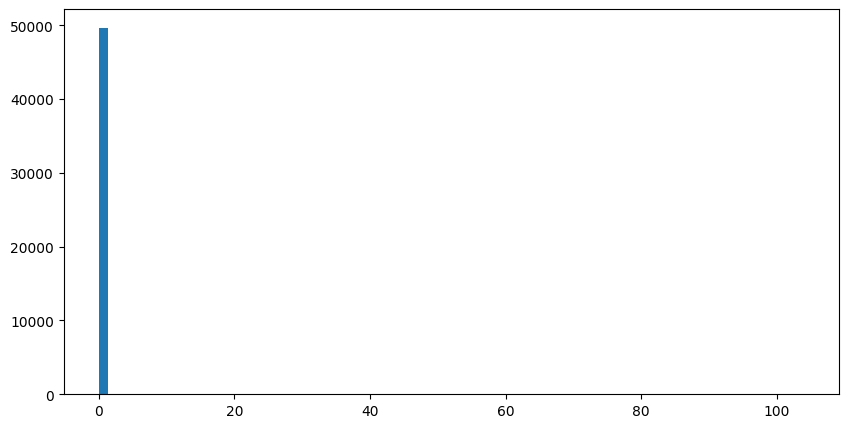

In [27]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_losses / 1e6, bins=80)
plt.axvline(VaR_99 / 1e6, linestyle="--", label="VaR 99%")
plt.axvline(VaR_999 / 1e6, linestyle="--", label="VaR 99.9%")
plt.title("Simulated Portfolio Credit Loss Distribution")
plt.xlabel("Portfolio Loss ($ millions)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 23. Tail-risk attribution by sector

### Additional explanation
This section asks where extreme losses come from. A sector may have modest average loss but a large tail-loss contribution if it has concentrated exposures or high correlation under stress.

This is a practical risk-management output because it identifies sectors that drive capital consumption.

In [ ]:
losses_df = pd.DataFrame(losses, columns=merton_inputs["ticker"])

sector_loss_paths = {}

for sector in sector_names:
    sector_tickers = merton_inputs.loc[
        merton_inputs["sector_group"] == sector, "ticker"
    ].tolist()
    sector_loss_paths[sector] = losses_df[sector_tickers].sum(axis=1).values

sector_losses = pd.DataFrame(sector_loss_paths)

tail_mask_999 = portfolio_losses >= VaR_999

tail_sector_loss = sector_losses[tail_mask_999].mean()
expected_sector_loss = sector_losses.mean()

tail_attribution = pd.DataFrame({
    "sector_group": sector_names,
    "expected_loss": [expected_sector_loss[s] for s in sector_names],
    "tail_loss_999": [tail_sector_loss[s] for s in sector_names],
})

tail_attribution["expected_loss_mn"] = tail_attribution["expected_loss"] / 1e6
tail_attribution["tail_loss_999_mn"] = tail_attribution["tail_loss_999"] / 1e6
tail_attribution["tail_loss_share"] = (
    tail_attribution["tail_loss_999"] / tail_attribution["tail_loss_999"].sum()
)

tail_attribution.sort_values("tail_loss_999", ascending=False)

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(tail_attribution["sector_group"], tail_attribution["tail_loss_share"])
plt.title("Sector Contribution to 99.9% Tail Loss")
plt.xlabel("Sector")
plt.ylabel("Share of 99.9% Tail Loss")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 23.1 Concentrated-EAD scenario

The equal-EAD baseline is clean, but real wholesale portfolios are often concentrated.

Now we rerun the same simulation using the capped lognormal EADs. This shows how exposure concentration can change portfolio VaR, Expected Shortfall, and sector tail-loss attribution.

### Additional explanation
The concentrated-EAD scenario intentionally introduces exposure concentration. Comparing it with equal EAD shows whether portfolio risk is driven more by default probabilities/correlation or by large borrower exposures.

This turns concentration risk into a clear scenario analysis rather than an accidental modeling artifact.

In [ ]:
concentrated_results = run_credit_portfolio_simulation(
    merton_inputs,
    ead_col="ead_concentrated",
    n_sims=50_000,
    seed=42
)

portfolio_losses_conc = concentrated_results["portfolio_losses"]
losses_conc = concentrated_results["losses"]
defaults_conc = concentrated_results["defaults"]

risk_metrics_conc = calculate_risk_metrics(portfolio_losses_conc)

scenario_comparison = risk_metrics[["metric", "value_mn"]].merge(
    risk_metrics_conc[["metric", "value_mn"]],
    on="metric",
    suffixes=("_equal_ead", "_concentrated_ead")
)

scenario_comparison

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_losses / 1e6, bins=80, alpha=0.6, label="Equal EAD")
plt.hist(portfolio_losses_conc / 1e6, bins=80, alpha=0.6, label="Concentrated EAD")
plt.title("Portfolio Loss Distribution: Equal vs Concentrated EAD")
plt.xlabel("Portfolio Loss ($ millions)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
merton_inputs["ead_concentrated_weight"] = (
    merton_inputs["ead_concentrated"] / merton_inputs["ead_concentrated"].sum()
)

concentrated_single_name = merton_inputs[[
    "ticker", "sector_group", "ead_concentrated", "ead_concentrated_weight", "pd_model", "lgd"
]].copy()

concentrated_single_name["ead_concentrated_mn"] = (
    concentrated_single_name["ead_concentrated"] / 1e6
)

concentrated_single_name.sort_values("ead_concentrated_weight", ascending=False).head(15)

## 24. Save final outputs

### Additional explanation
Saving outputs supports reproducibility and later reporting. Future notebooks can load these CSVs directly for stress testing, governance documentation, and visualization without rerunning data downloads.

In [ ]:
merton_inputs.to_csv("firm_level_merton_and_portfolio_inputs.csv", index=False)
risk_metrics.to_csv("portfolio_risk_metrics_equal_ead.csv", index=False)
risk_metrics_conc.to_csv("portfolio_risk_metrics_concentrated_ead.csv", index=False)
scenario_comparison.to_csv("portfolio_scenario_comparison.csv", index=False)
tail_attribution.to_csv("sector_tail_risk_attribution_equal_ead.csv", index=False)

pd.Series(portfolio_losses, name="portfolio_loss_equal_ead").to_csv(
    "portfolio_loss_simulations_equal_ead.csv",
    index=False
)

pd.Series(portfolio_losses_conc, name="portfolio_loss_concentrated_ead").to_csv(
    "portfolio_loss_simulations_concentrated_ead.csv",
    index=False
)

print("Saved:")
print("- firm_level_merton_and_portfolio_inputs.csv")
print("- portfolio_risk_metrics_equal_ead.csv")
print("- portfolio_risk_metrics_concentrated_ead.csv")
print("- portfolio_scenario_comparison.csv")
print("- sector_tail_risk_attribution_equal_ead.csv")
print("- portfolio_loss_simulations_equal_ead.csv")
print("- portfolio_loss_simulations_concentrated_ead.csv")

## 25. Summary and next extensions

This notebook built an end-to-end wholesale credit portfolio simulation framework.

It covered:

1. public-company borrower universe,
2. market and debt data,
3. equity volatility,
4. simplified Merton distance-to-default and PD,
5. market/sector factor calibration,
6. equal-EAD baseline exposure design,
7. concentrated-EAD scenario design,
8. correlated default simulation,
9. portfolio loss distribution,
10. Expected Loss, Credit VaR, Expected Shortfall, and economic capital,
11. sector tail-risk attribution.

### Why equal EAD and concentrated EAD are both useful

The **equal-EAD baseline** is useful because it reduces mechanical exposure concentration and makes the model easier to interpret.

The **concentrated-EAD scenario** is useful because real wholesale portfolios often have unequal exposures, and tail risk can be driven by a small number of large borrowers.

### Suggested next extensions

1. **Stress testing**
   - global recession,
   - sector shock,
   - correlation stress,
   - LGD stress,
   - downgrade wave.

2. **Full Merton calibration**
   - solve nonlinear Black-Scholes equity-as-call equations for asset value and asset volatility.

3. **PCA factor model**
   - estimate systematic factors directly from the return covariance matrix.

4. **Model governance report**
   - assumptions,
   - limitations,
   - validation checks,
   - sensitivity analysis,
   - business interpretation.

### Additional explanation
At this point, the notebook provides a full baseline credit portfolio engine. The most valuable next step is stress testing: increase PDs, increase LGDs, shock selected sectors, or increase correlations, then compare tail losses and economic capital.

This is where the project becomes especially relevant to credit risk management and consulting work.